# Load Built-in Dataset

In [2]:
from surprise import Dataset, Reader

# Path to the u.data file
file_path = r"C:\Users\pouya\Downloads\Recommender_system-master\Recommender_system-master\dataset\dataset\ml-100k\u.data"

# Define the format (user, item, rating, timestamp)
reader = Reader(line_format='user item rating timestamp', sep='\t')

# Load the dataset
data = Dataset.load_from_file(file_path, reader=reader)

type(data)

surprise.dataset.DatasetAutoFolds

# Data Splitting & Exploration

In [3]:
from surprise.model_selection import train_test_split

# 80% train, 20% test
trainset, testset = train_test_split(data=data,
                                         test_size=0.2,
                                         random_state=43)

# Here trainset is a Trainset object but testset is a list
print(f"Train data: {trainset.n_ratings}")
print(f"Test data: {len(testset)}")
print(f"Train users: {trainset.n_users}")
print(f"Train items: {trainset.n_items}")

Train data: 80000
Test data: 20000
Train users: 943
Train items: 1645


## Model Training: SVD (Singular Value Decomposition)

In [4]:
from surprise import SVD

# Initialize SVD model
svd_model = SVD(n_factors=100,  # latent factros (number of hidden features)
                n_epochs=20,    # Training iterations
                lr_all=0.005,   # Learning rate
                reg_all=0.02)   # Regularization

# Train on 80% of data
svd_model.fit(trainset)

## Making Predictions with the Trained SVD Model


In [5]:
svd_model.predict(uid="10", iid="196"), svd_model.predict(uid="25", iid="365")

(Prediction(uid='10', iid='196', r_ui=None, est=4.182078959054981, details={'was_impossible': False}),
 Prediction(uid='25', iid='365', r_ui=None, est=3.2707077073956303, details={'was_impossible': False}))

## Hyperparameter Tuning with GridSearchCV


In [ ]:
from surprise.model_selection import GridSearchCV

# Define hyperparameter grid to search
svd_param_grid = {
    "n_factors": [50, 100, 150],
    "n_epochs": [20, 30],
    "lr_all": [0.005, 0.01, 0.001],
    "reg_all":[0.02, 0.1]
}

# 3-fold cross-validation to find the best parameters
svd_gs = GridSearchCV(algo_class=SVD,
                      param_grid=svd_param_grid,
                      measures=["rmse", "mae"], 
                      cv=3)

# Run search on all data
svd_gs.fit(data)

## Training Final Model with The Best Parameters

In [7]:
# Unpack best parameters and initialize SVD
best_svd_model = SVD(**svd_gs.best_params["rmse"])
best_svd_model.fit(trainset)

## Model Evaluation


In [46]:
from surprise import accuracy

# Generate predictions on test set (unseen data)
svd_predictions = svd_model.test(testset)

# Calculate evaluations metrics
svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

RMSE: 0.9421
MAE:  0.7440


## Making Predictions with the Trained Model

In [9]:
best_svd_model.predict(uid="10", iid="196"), best_svd_model.predict(uid="25", iid="365")

(Prediction(uid='10', iid='196', r_ui=None, est=4.168155597371289, details={'was_impossible': False}),
 Prediction(uid='25', iid='365', r_ui=None, est=3.4524425313120553, details={'was_impossible': False}))

## KNNBaseline Model Tuning with GridSearchCV


In [ ]:
from surprise import KNNBaseline
from surprise.model_selection import GridSearchCV

knn_param_grid = {
    'k': [40, 60],       # Number of neighbors to consider
    'min_k': [1, 3, 5],  # Minimum neighbors when k not available
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True, False]  # True = user-user, False = item-item
    }
}

knn_gs = GridSearchCV(algo_class=KNNBaseline,
                      param_grid=knn_param_grid,
                      measures=['rmse', 'mae'], 
                      cv=3)

knn_gs.fit(data=data)

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Com

## Get Best Params & Create New Model With Best Params


In [17]:
best_knn_params = knn_gs.best_params['rmse']
best_knn_model = KNNBaseline(**best_knn_params)

## Training the Best KNNBaseline Model


In [18]:
best_knn_model.fit(trainset)

Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.


## Calculate RMSE and MAE for best KNN model on testset

In [ ]:
from surprise import accuracy

knn_predictions = best_knn_model.test(testset)
knn_rmse = accuracy.rmse(knn_predictions)
knn_mae = accuracy.mae(knn_predictions)

RMSE: 0.9352
MAE:  0.7374


## Baseline Only Model Tuning with GridSearchCV


In [ ]:
from surprise import BaselineOnly
from surprise.model_selection import GridSearchCV

baseline_param_grid = {
        'bsl_options': {
        'method': ['sgd', 'als'],  # Optimization algorithm: SGD or ALS
        'n_epochs': [20, 30],      # Number of training iterations
        'reg': [0.02, 0.1]         # Regularization term      
    }
}

baseline_gs = GridSearchCV(algo_class=BaselineOnly,
                           param_grid=baseline_param_grid,
                           measures=['rmse','mae'],
                           cv=3,
                           refit=True)

baseline_gs.fit(data=data)

Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using sgd...


## Get Best Params & Create New Model With Best Params

In [21]:
best_baseline_params = baseline_gs.best_params['rmse']
best_baseline_model = KNNBaseline(**best_baseline_params)

## Training the Best BaselineOnly Model


In [22]:
best_baseline_model.fit(trainset)

Estimating biases using sgd...
Computing the msd similarity matrix...
Done computing similarity matrix.


## Evaluating KNN Baseline Model on Test Set

In [23]:
from surprise import accuracy

baseline_predictions = best_baseline_model.test(testset)
baseline_rmse = accuracy.rmse(baseline_predictions)
baseline_mae = accuracy.mae(baseline_predictions)

RMSE: 0.9383
MAE:  0.7397


## SlopeOne Model - Cross-Validation


In [ ]:
from surprise import SlopeOne
from surprise.model_selection import cross_validate
from surprise import accuracy

slopeone_model = SlopeOne()

slopeone_results = cross_validate(algo=slopeone_model,
                                  data=data,
                                  measures=["rmse", "mae"],
                                  cv=5,
                                  verbose=True)     # Print progress

slopeone_rmse = slopeone_results['test_rmse'].mean()
slopeone_mae = slopeone_results['test_mae'].mean()

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9454  0.9472  0.9375  0.9422  0.9511  0.9447  0.0046  
MAE (testset)     0.7422  0.7435  0.7374  0.7412  0.7484  0.7425  0.0036  
Fit time          0.63    0.63    0.63    0.63    0.65    0.63    0.01    
Test time         1.59    1.64    1.58    1.63    1.52    1.59    0.04    


## Evaluating SlopeOne

In [25]:
print(f"RMSE: {slopeone_rmse:.4f}")
print(f"MAE:  {slopeone_mae:.4f}")

RMSE: 0.9447
MAE:  0.7425


In [26]:
svd_rmse, knn_rmse, baseline_rmse, slopeone_rmse

(0.9420522026465369,
 0.9352056208085388,
 0.9383104453243076,
 0.9446724087584295)

## RMSE Comparison Bar Chart

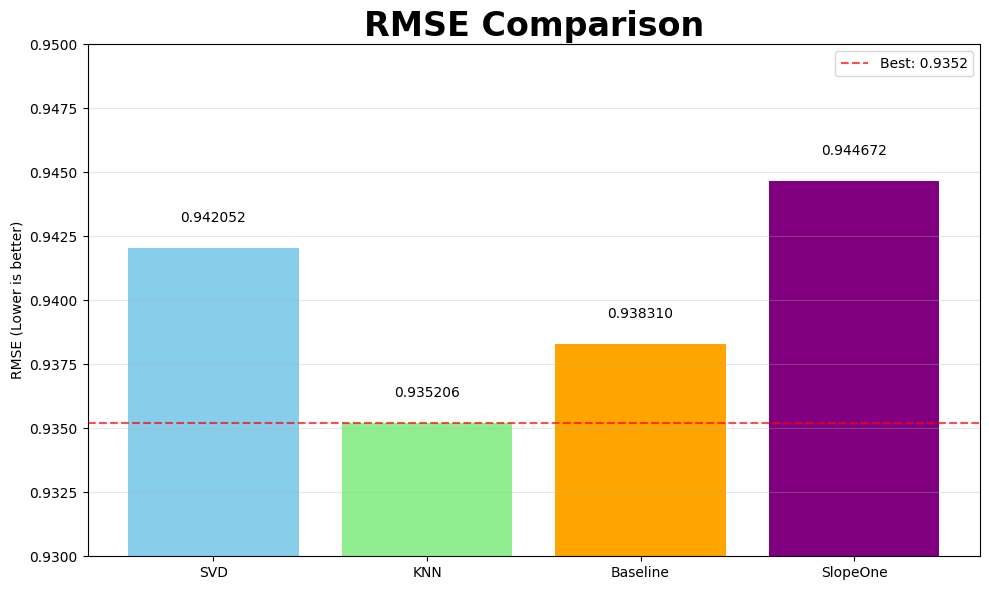

In [27]:
import matplotlib.pyplot as plt

models = ['SVD', 'KNN', 'Baseline', 'SlopeOne']
rmse_values = [svd_rmse, knn_rmse, baseline_rmse, slopeone_rmse]

plt.figure(figsize=(10, 6))

plt.bar(x=models,
        height=rmse_values,
        color=['skyblue', 'lightgreen', 'orange', 'purple'])

plt.ylabel("RMSE (Lower is better)")

plt.title("RMSE Comparison", 
          fontsize=24, 
          fontweight='bold')

# Zoom y-axis 
plt.ylim(0.93, 0.95)

# add light horizontal grid lines
plt.grid(axis='y', alpha=0.3)

# Find the best (lowest) RMSE value
min_rmse = min(rmse_values)

# Draw horizontal dashed line at the best RMSE value
plt.axhline(y=min_rmse,
            color='red',
            linestyle="--",
            alpha=0.7,
            label = f"Best: {min_rmse:.4f}")

# Add RMSE value labels on top of each bar
for index, value in enumerate(rmse_values):
    # Adds text at position(x, y)
    plt.text(x= index,               # X-coordinate
             y = value + 0.001,      # y-coordinate + slight value to place it above the bar
             s = f'{value:4f}',      # string
             ha='center')            # horizontal alignment

plt.legend()

plt.tight_layout()
plt.show()


## Evaluating The Best Model on Test Set

In [45]:
# Set the best model for evaluation
best_model = best_knn_model

# Loop through first 10 test cases
for i, (user, item, rating) in enumerate(testset[:10]):

    # Generate prediction and roudn to 2 decimals
    pred = round(best_model.predict(str(user), str(item)).est, 2)

    # Show only predictions with error <=1
    if abs(pred - rating) <= 1.0:
        print(f"User {user} → Item {item}: Real: {rating} → Predicted: {pred}")

User 160 → Item 150: Real: 4.0 → Predicted: 4.19
User 95 → Item 65: Real: 4.0 → Predicted: 3.36
User 347 → Item 97: Real: 4.0 → Predicted: 3.92
User 927 → Item 763: Real: 4.0 → Predicted: 3.65
User 883 → Item 277: Real: 4.0 → Predicted: 3.44
User 682 → Item 298: Real: 4.0 → Predicted: 3.62
User 233 → Item 521: Real: 5.0 → Predicted: 4.14
User 456 → Item 743: Real: 2.0 → Predicted: 2.37


# Evaluate KNN model
## Count testset predictions within 1.0 star of actual ratings

In [44]:
# Set the best model for evaluation
best_model = best_knn_model

counter = 0

# Loop through first 10 test cases
for i, (user, item, rating) in enumerate(testset):

    # Generate prediction and roudn to 2 decimals
    pred = round(best_model.predict(str(user), str(item)).est, 2)

    # Show only predictions with error <=1
    if abs(pred - rating) <= 1.0:
        counter += 1

print(f"Predictions within 1.0: {counter} out of {len(testset)}\nAccuracy: {counter / len(testset) * 100:.2f}%")

Predictions within 1.0: 14648 out of 20000
Accuracy: 73.24%
